# DimeNet++ Alpha/Beta HOMO-LUMO Gap Prediction

Predicts both alpha and beta HOMO-LUMO gaps using DimeNet++ with masked loss.
- Dual output (n, 2) for alpha/beta gaps
- Masked loss for open-shell vs closed-shell molecules
- Best hyperparameters from tuning sweep (lr=1e-3, wd=1e-3, num_blocks=4)
- EMA (decay=0.999), ReduceLROnPlateau, gradient clipping
- No extra embedded features - pure geometric message passing

In [ ]:
# Install dependencies
!pip install -q torch==2.5.0 --index-url https://download.pytorch.org/whl/cu121
!pip install -q torch_geometric
!pip install -q torch_cluster torch_scatter torch_sparse -f https://data.pyg.org/whl/torch-2.5.0+cu121.html
!pip install -q ase
!pip install -q --force-reinstall --no-deps "fairchem-core<2.0"
!pip install -q lmdb ase-db-backends e3nn hydra-core pymatgen submitit torchtnt

print("RESTART THE RUNTIME SESSION NOW")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 780.4/780.4 MB 1.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.7/23.7 MB 113.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 823.6/823.6 kB 57.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.1/14.1 MB 132.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 410.6/410.6 MB 3.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 121.6/121.6 MB 22.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.5/56.5 MB 46.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 124.2/124.2 MB 8.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 196.0/196.0 MB 5.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 188.7/188.7 MB 6.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.1/99.1 kB 10.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━

In [ ]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from torch_geometric.nn import DimeNetPlusPlus
from torch_geometric.loader import DataLoader
from read_multi_ase_ab import *
from extract_ab_simple import *

## Model + EMA

In [ ]:
class EMA:
    def __init__(self, model, decay=0.999):
        self.decay = decay
        self.shadow = {k: v.clone() for k, v in model.state_dict().items()}

    def update(self, model):
        for k, v in model.state_dict().items():
            self.shadow[k] = self.decay * self.shadow[k] + (1 - self.decay) * v

    def apply(self, model):
        model.load_state_dict(self.shadow)


class DimeNetPP_AlphaBeta(nn.Module):
    def __init__(self, hidden_channels=64, num_blocks=4, int_emb_size=64,
                 basis_emb_size=8, out_emb_channels=128, num_spherical=7,
                 num_radial=6, cutoff=5.0, train_mean=None, train_std=None):
        super().__init__()
        self.dimenet = DimeNetPlusPlus(
            hidden_channels=hidden_channels,
            out_channels=2,
            num_blocks=num_blocks,
            int_emb_size=int_emb_size,
            basis_emb_size=basis_emb_size,
            out_emb_channels=out_emb_channels,
            num_spherical=num_spherical,
            num_radial=num_radial,
            cutoff=cutoff,
        )
        self.mean = train_mean
        self.std = train_std

    def forward(self, data):
        return self.dimenet(data.z, data.pos, batch=data.batch)

## Training and Evaluation

In [ ]:
def train(model, loader):
    model.train()
    total_loss = 0
    loss_fn = nn.SmoothL1Loss(reduction='none')
    for data in loader:
        data = data.to(device)
        optimizer.zero_grad()
        pred = model(data)
        target = data.y.view(-1, 2)
        mask = data.y_mask.view(-1, 2)
        loss = (loss_fn(pred, target) * mask).sum() / mask.sum()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=10.0)
        optimizer.step()
        ema.update(model)
        total_loss += loss.item()
    return total_loss / len(loader)


@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    total_loss = 0
    loss_fn = nn.SmoothL1Loss(reduction='none')
    for data in loader:
        data = data.to(device)
        pred = model(data)
        target = data.y.view(-1, 2)
        mask = data.y_mask.view(-1, 2)
        loss = (loss_fn(pred, target) * mask).sum() / mask.sum()
        total_loss += loss.item()
    return total_loss / len(loader)


@torch.no_grad()
def test(model, loader):
    model.eval()
    total_mae = 0
    total_mse = 0
    n = 0
    mean = model.mean.to(device)
    std = model.std.to(device)
    for data in loader:
        data = data.to(device)
        pred = model(data)
        target = data.y.view(-1, 2)
        mask = data.y_mask.view(-1, 2)
        pred_eV = (pred * std + mean) * mask
        target_eV = (target * std + mean) * mask
        total_mae += torch.abs(pred_eV - target_eV).sum().item()
        total_mse += ((pred_eV - target_eV) ** 2).sum().item()
        n += mask.sum().item()
    return total_mae / n, (total_mse / n) ** 0.5


def plot_losses(train_losses, val_losses):
    plt.figure(figsize=(10, 6))
    plt.plot(train_losses, label='Train Loss', linewidth=2)
    plt.plot(val_losses, label='Validation Loss', linewidth=2)
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('DimeNet++ Alpha/Beta Training')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

In [ ]:
def get_data(dataset):
    result = []
    for i, mol in enumerate(dataset):
        try:
            atoms = mol[0]
            z = torch.tensor(atoms.get_atomic_numbers(), dtype=torch.long)
            pos = torch.tensor(atoms.get_positions(), dtype=torch.float)

            homo_lumo_gap = atoms.info["homo_lumo_gap"]
            spin = atoms.info["spin"]

            y = torch.zeros(2, dtype=torch.float)
            y_mask = torch.zeros(2, dtype=torch.float)

            if spin > 1:
                y[0] = homo_lumo_gap[0]
                y[1] = homo_lumo_gap[1]
                y_mask[:] = 1
            else:
                if isinstance(homo_lumo_gap, (list, tuple, np.ndarray)):
                    y[0] = homo_lumo_gap[0]
                else:
                    y[0] = homo_lumo_gap
                y_mask[0] = 1

            result.append(Data(z=z, pos=pos, y=y, y_mask=y_mask))
        except Exception as e:
            print(f"Error at molecule {i}: {e}")
            print(f"  spin={atoms.info.get('spin')}, gap={atoms.info.get('homo_lumo_gap')}")
            continue

    print(f"Processed {len(result)} molecules")
    return result

## Run 1: 1000 Biomolecules (Baseline)

In [ ]:
bio_sample = process_file(file="/content/data0000.aselmdb", molecule_type="biomolecules", max_molecules=1000)
bio_data = get_data(bio_sample)
bio_train, bio_val, bio_test = split_data(bio_data)

train_mean, train_std = obtain_mean_std(bio_train)
bio_train = normalize_target(bio_train, train_mean, train_std)
bio_val = normalize_target(bio_val, train_mean, train_std)
bio_test = normalize_target(bio_test, train_mean, train_std)

bio_train_loader = DataLoader(bio_train, batch_size=32, shuffle=True)
bio_val_loader = DataLoader(bio_val, batch_size=32)
bio_test_loader = DataLoader(bio_test, batch_size=32)

print(f"Train: {len(bio_train)}, Val: {len(bio_val)}, Test: {len(bio_test)}")
print(f"Mean: {train_mean}, Std: {train_std}")

Processed 1000 molecules
Train: 640, Val: 160, Test: 200
Mean: tensor([8.3087, 7.1851]), Std: tensor([2.0231, 2.3181])


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = DimeNetPP_AlphaBeta(
    hidden_channels=64,
    num_blocks=4,
    int_emb_size=64,
    basis_emb_size=8,
    out_emb_channels=128,
    num_spherical=7,
    num_radial=6,
    cutoff=5.0,
    train_mean=train_mean,
    train_std=train_std,
).to(device)

optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-3)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=10)
ema = EMA(model, decay=0.999)

print(f"Model parameters: {sum(p.numel() for p in model.parameters()):,}")

Model parameters: 498,886


In [ ]:
epochs = 200
patience = 30
best_val = float('inf')
patience_counter = 0
train_losses, val_losses = [], []

for epoch in range(epochs):
    t_loss = train(model, bio_train_loader)
    v_loss = evaluate(model, bio_val_loader)
    scheduler.step(v_loss)
    train_losses.append(t_loss)
    val_losses.append(v_loss)

    if v_loss < best_val:
        best_val = v_loss
        patience_counter = 0
    else:
        patience_counter += 1

    if epoch % 10 == 0:
        print(f"Epoch {epoch+1:03d} | Train: {t_loss:.4f} | Val: {v_loss:.4f} | Patience: {patience_counter}/{patience}")

    if patience_counter >= patience:
        print(f"Early stopping at epoch {epoch+1}")
        break

# Apply EMA weights for evaluation
ema.apply(model)
print(f"\nBest Val Loss: {best_val:.4f}")

Epoch 001 | Train: 0.9045 | Val: 0.3500 | Patience: 0/30
Epoch 011 | Train: 0.3216 | Val: 0.3170 | Patience: 6/30
Epoch 021 | Train: 0.2124 | Val: 0.2770 | Patience: 2/30
Epoch 031 | Train: 0.1129 | Val: 0.3149 | Patience: 9/30
Epoch 041 | Train: 0.0150 | Val: 0.3041 | Patience: 19/30
Epoch 051 | Train: 0.0009 | Val: 0.3088 | Patience: 29/30
Early stopping at epoch 52

Best Val Loss: 0.2466


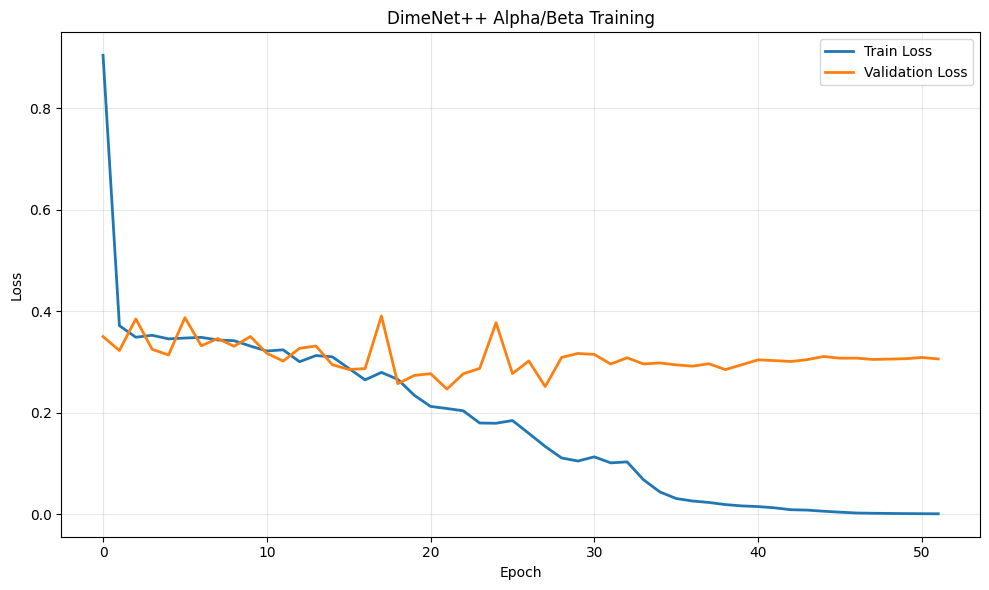

In [ ]:
plot_losses(train_losses, val_losses)

In [ ]:
mae, rmse = test(model, bio_test_loader)
print(f"Test MAE: {mae:.4f}")
print(f"Test RMSE: {rmse:.4f}")

Test MAE: 1.5176
Test RMSE: 2.0373


## Run 2: 10000 Biomolecules (Scale Up)

In [ ]:
bio_sample = process_file(file="/content/data0000.aselmdb", molecule_type="biomolecules", max_molecules=10000)
bio_data = get_data(bio_sample)
bio_train, bio_val, bio_test = split_data(bio_data)

train_mean, train_std = obtain_mean_std(bio_train)
bio_train = normalize_target(bio_train, train_mean, train_std)
bio_val = normalize_target(bio_val, train_mean, train_std)
bio_test = normalize_target(bio_test, train_mean, train_std)

bio_train_loader = DataLoader(bio_train, batch_size=32, shuffle=True)
bio_val_loader = DataLoader(bio_val, batch_size=32)
bio_test_loader = DataLoader(bio_test, batch_size=32)

print(f"Train: {len(bio_train)}, Val: {len(bio_val)}, Test: {len(bio_test)}")
print(f"Mean: {train_mean}, Std: {train_std}")

Processed 10000 molecules
Train: 6400, Val: 1600, Test: 2000
Mean: tensor([8.2021, 6.8064]), Std: tensor([2.0582, 2.0056])


In [ ]:
model = DimeNetPP_AlphaBeta(
    hidden_channels=64,
    num_blocks=4,
    int_emb_size=64,
    basis_emb_size=8,
    out_emb_channels=128,
    num_spherical=7,
    num_radial=16,
    cutoff=5.0,
    train_mean=train_mean,
    train_std=train_std,
).to(device)

optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-3)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=10)
ema = EMA(model, decay=0.999)

print(f"Model parameters: {sum(p.numel() for p in model.parameters()):,}")

Model parameters: 505,296


In [ ]:
epochs = 200
patience = 30
best_val = float('inf')
patience_counter = 0
train_losses, val_losses = [], []

for epoch in range(epochs):
    t_loss = train(model, bio_train_loader)
    v_loss = evaluate(model, bio_val_loader)
    scheduler.step(v_loss)
    train_losses.append(t_loss)
    val_losses.append(v_loss)

    if v_loss < best_val:
        best_val = v_loss
        patience_counter = 0
    else:
        patience_counter += 1

    if epoch % 10 == 0:
        print(f"Epoch {epoch+1:03d} | Train: {t_loss:.4f} | Val: {v_loss:.4f} | Patience: {patience_counter}/{patience}")

    if patience_counter >= patience:
        print(f"Early stopping at epoch {epoch+1}")
        break

ema.apply(model)
print(f"\nBest Val Loss: {best_val:.4f}")

Epoch 001 | Train: 0.5115 | Val: 0.3298 | Patience: 0/30
Epoch 011 | Train: 0.2502 | Val: 0.2648 | Patience: 0/30
Epoch 021 | Train: 0.1417 | Val: 0.2548 | Patience: 2/30
Epoch 031 | Train: 0.0634 | Val: 0.2457 | Patience: 0/30
Epoch 041 | Train: 0.0258 | Val: 0.2527 | Patience: 10/30
Epoch 051 | Train: 0.0077 | Val: 0.2541 | Patience: 20/30
Epoch 061 | Train: 0.0020 | Val: 0.2474 | Patience: 30/30
Early stopping at epoch 61

Best Val Loss: 0.2457


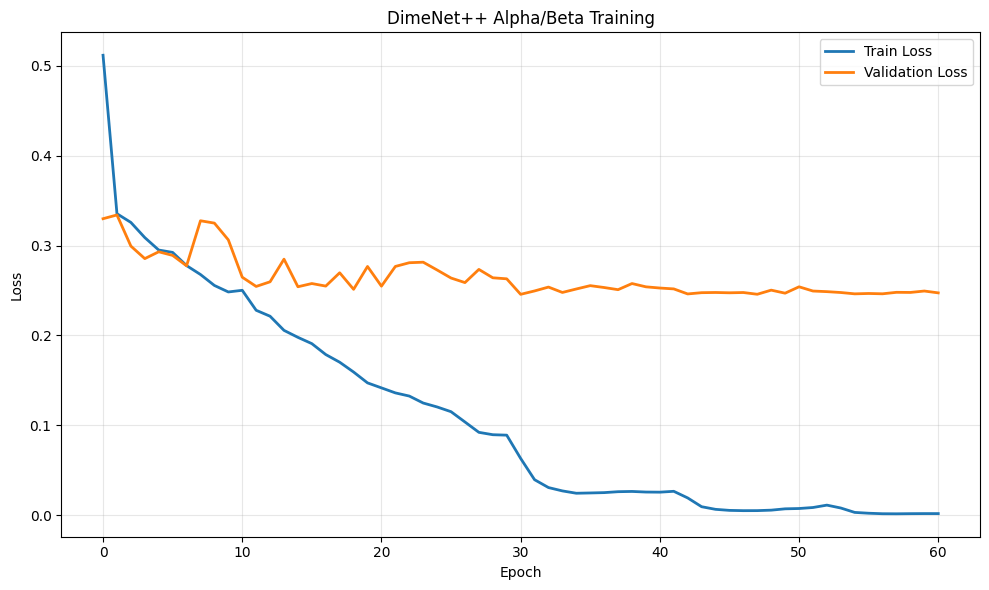

In [ ]:
plot_losses(train_losses, val_losses)

In [ ]:
mae, rmse = test(model, bio_test_loader)
print(f"Test MAE: {mae:.4f}")
print(f"Test RMSE: {rmse:.4f}")

Test MAE: 1.1376
Test RMSE: 1.7729


In [ ]:
@torch.no_grad()
def test_alpha_only(model, loader):
    model.eval()
    total_mae = 0
    n = 0
    mean = model.mean.to(device)
    std = model.std.to(device)
    for data in loader:
        data = data.to(device)
        pred = model(data)
        target = data.y.view(-1, 2)
        # Alpha only (column 0)
        pred_eV = pred[:, 0] * std[0] + mean[0]
        target_eV = target[:, 0] * std[0] + mean[0]
        total_mae += torch.abs(pred_eV - target_eV).sum().item()
        n += len(pred)
    return total_mae / n

print(f"Alpha-only MAE: {test_alpha_only(model, bio_test_loader):.4f}")

Alpha-only MAE: 1.0894


hmmm ema might be hurting with the 2 output version - use best_state in next notebook with attention stuff

In [ ]:
# Run without EMA — 1000 mol, same config
model = DimeNetPP_AlphaBeta(
    hidden_channels=64,
    num_blocks=4,
    int_emb_size=64,
    basis_emb_size=8,
    out_emb_channels=128,
    num_spherical=7,
    num_radial=6,
    cutoff=5.0,
    train_mean=train_mean,
    train_std=train_std,
).to(device)

optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-3)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=10)

epochs = 200
patience = 30
best_val = float('inf')
patience_counter = 0
best_state = None
train_losses, val_losses = [], []

for epoch in range(epochs):
    model.train()
    total_loss = 0
    loss_fn = nn.SmoothL1Loss(reduction='none')
    for data in bio_train_loader:
        data = data.to(device)
        optimizer.zero_grad()
        pred = model(data)
        target = data.y.view(-1, 2)
        mask = data.y_mask.view(-1, 2)
        loss = (loss_fn(pred, target) * mask).sum() / mask.sum()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=10.0)
        optimizer.step()
        total_loss += loss.item()
    t_loss = total_loss / len(bio_train_loader)

    v_loss = evaluate(model, bio_val_loader)
    scheduler.step(v_loss)
    train_losses.append(t_loss)
    val_losses.append(v_loss)

    if v_loss < best_val:
        best_val = v_loss
        best_state = {k: v.clone() for k, v in model.state_dict().items()}
        patience_counter = 0
    else:
        patience_counter += 1

    if epoch % 10 == 0:
        print(f"Epoch {epoch+1:03d} | Train: {t_loss:.4f} | Val: {v_loss:.4f} | Patience: {patience_counter}/{patience}")

    if patience_counter >= patience:
        print(f"Early stopping at epoch {epoch+1}")
        break

model.load_state_dict(best_state)
print(f"\nBest Val Loss: {best_val:.4f}")

mae, rmse = test(model, bio_test_loader)
print(f"Test MAE: {mae:.4f}")
print(f"Test RMSE: {rmse:.4f}")

Exception ignored in: <function AseDBDataset.__del__ at 0x7f0288eeafc0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/fairchem/core/datasets/ase_datasets.py", line 565, in __del__
    for db in self.dbs:
              ^^^^^^^^
AttributeError: 'MultiAseDBDataset' object has no attribute 'dbs'


Epoch 001 | Train: 0.5744 | Val: 0.3418 | Patience: 0/30
Epoch 011 | Train: 0.2842 | Val: 0.2791 | Patience: 0/30
Epoch 021 | Train: 0.2053 | Val: 0.2591 | Patience: 2/30
Epoch 031 | Train: 0.1058 | Val: 0.2685 | Patience: 6/30
Epoch 041 | Train: 0.0267 | Val: 0.2674 | Patience: 16/30
Epoch 051 | Train: 0.0079 | Val: 0.2682 | Patience: 26/30
Early stopping at epoch 55

Best Val Loss: 0.2509
Test MAE: 1.1025
Test RMSE: 1.7616
